In [1]:
# Run this cell first to import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models.segmentation as segmentation
from torchvision.models.segmentation.deeplabv3 import DeepLabHead, DeepLabV3_ResNet101_Weights
from transformers import SegformerForSemanticSegmentation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Enable interactive plotting
%matplotlib inline

Using device: cuda


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
from transformers import SegformerForSemanticSegmentation

# ==========================================
# 1. CBAM Components (unchanged)
# ==========================================
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=4):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        
        x_cat = torch.cat([avg_out, max_out], dim=1)
        out = self.conv1(x_cat)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, channels=19, reduction=4, spatial_kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(channels, ratio=reduction)
        self.sa = SpatialAttention(kernel_size=spatial_kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# ==========================================
# 2. Main Model → MODIFIED: ONLY pollutant (1 output)
# ==========================================
class PollutionDifferenceModel(nn.Module):
    def __init__(self, num_classes=19, pollution_dims=1):  # ✅ 5 → 1
        super(PollutionDifferenceModel, self).__init__()
        
        self.backbone = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/segformer-b5-finetuned-cityscapes-1024-1024",
            use_safetensors=True 
        )
        
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        self.cbam = CBAM(channels=num_classes)
        
        self.convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        for param in self.convnext.parameters():
            param.requires_grad = True
        
        original_stem = self.convnext.features[0][0]
        self.convnext.features[0][0] = nn.Conv2d(
            in_channels=num_classes,
            out_channels=original_stem.out_channels,
            kernel_size=original_stem.kernel_size,
            stride=original_stem.stride,
            padding=original_stem.padding,
            bias=(original_stem.bias is not None)
        )
        nn.init.kaiming_normal_(self.convnext.features[0][0].weight, mode='fan_out', nonlinearity='relu')
        
        self.convnext.classifier[2] = nn.Identity() 
        convnext_out_dim = 768
        
        # ✅ Final output = 1 (pollutant only)
        self.mlp_decoder = nn.Sequential(
            nn.Linear(convnext_out_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, pollution_dims)
        )

    def get_semantic_map(self, x):
        outputs = self.backbone(pixel_values=x)
        seg_logits = outputs.logits  
        probs = torch.nn.functional.softmax(seg_logits, dim=1) 
        return probs

    def forward(self, imgA, imgB):
        mapA = self.get_semantic_map(imgA)  
        mapB = self.get_semantic_map(imgB)  
        diff_map = mapA - mapB  
        attended_diff_map = self.cbam(diff_map) 
        z_diff = self.convnext(attended_diff_map)
        pred_pollution_delta = self.mlp_decoder(z_diff)
        return pred_pollution_delta

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import torchvision.transforms as T
from sklearn.model_selection import train_test_split

# ==========================================
# 3. Dataset → MODIFIED: ONLY pollutant
# ==========================================
# class PairedPollutionDataset(Dataset):
#     def __init__(self, dataframe, root_dir, transform=None):
#         self.df = dataframe.reset_index(drop=True)
#         self.root_dir = root_dir
#         self.transform = transform
#         self.pollution_cols = ['pollutant']  # Only pollutant
#         
#         valid_mask = self.df['Filename'].apply(lambda x: os.path.exists(os.path.join(self.root_dir, str(x))))
#         self.df = self.df[valid_mask].reset_index(drop=True)
# 
#         if 'Filename' not in self.df.columns:
#             raise ValueError("CSV must have a column named 'Filename'!")
# 
#     def __len__(self):
#         return len(self.df)
# 
#     def __getitem__(self, idx):
#         row_A = self.df.iloc[idx]
#         idx_B = idx
#         while idx_B == idx:
#             idx_B = torch.randint(0, len(self.df), (1,)).item()
#         row_B = self.df.iloc[idx_B]
# 
#         img_path_A = os.path.join(self.root_dir, str(row_A['Filename']))
#         img_path_B = os.path.join(self.root_dir, str(row_B['Filename']))
# 
#         try:
#             img_A = Image.open(img_path_A).convert('RGB')
#             img_B = Image.open(img_path_B).convert('RGB')
#         except Exception as e:
#             new_idx = torch.randint(0, len(self.df), (1,)).item()
#             return self.__getitem__(new_idx)
# 
#         if self.transform:
#             img_A = self.transform(img_A)
#             img_B = self.transform(img_B)
# 
#         # Only pollutant
#         vals_A = row_A[self.pollution_cols].values.astype('float32')
#         vals_B = row_B[self.pollution_cols].values.astype('float32')
# 
#         vals_A = torch.nan_to_num(torch.tensor(vals_A), nan=0.0)
#         vals_B = torch.nan_to_num(torch.tensor(vals_B), nan=0.0)
# 
#         pol_diff = vals_A - vals_B
#         return img_A, img_B, pol_diff
# 
# # --- Transforms & Data Loading ---
# transform = T.Compose([
#     T.Resize((256, 256)),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])
# 
# csv_path = "20251110_matched.csv"
# image_folder_path = "output_frames_20251110//"
# 
# from sklearn.model_selection import train_test_split
# 
# df_full = pd.read_csv(csv_path)
# df_train, df_temp = train_test_split(df_full, test_size=0.2, random_state=42)
# df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)
# 
# train_dataset = PairedPollutionDataset(dataframe=df_train, root_dir=image_folder_path, transform=transform)
# val_dataset = PairedPollutionDataset(dataframe=df_val, root_dir=image_folder_path, transform=transform)
# test_dataset = PairedPollutionDataset(dataframe=df_test, root_dir=image_folder_path, transform=transform)
# 
# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
# test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
# 
# print(f"Training: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

class PairedPollutionDataset(Dataset):
    def __init__(self, dataframe, root_dir, temporal_stride=5, multi_scale=True, transform=None):
        """
        temporal_stride (int): Time lag k.
        multi_scale (bool): 
            - If False: Single-scale pairing (match index i with i + k only).
            - If True: Multi-scale pairing (match index i with i+1, i+2 ... i+k for 5x data augmentation).
        """
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.temporal_stride = temporal_stride
        self.multi_scale = multi_scale
        self.pollution_cols = ['pollutant']
        print(f'temporal_stride: {temporal_stride}')
        print(f'multi pairing? : {multi_scale}')
        # Step 1. Filter records with missing image files
        if 'Filename' not in self.df.columns:
            raise ValueError("CSV must have a column named 'Filename' for image paths!")
            
        valid_mask = self.df['Filename'].apply(lambda x: os.path.exists(os.path.join(self.root_dir, str(x))))
        self.df = self.df[valid_mask].reset_index(drop=True)
        
        # Step 2. Precompute valid temporal index pair pool
        # This is a safe and efficient way to avoid complex boundary logic inside __getitem__
        self.pairs = []
        max_idx = len(self.df) - 1
        
        for i in range(len(self.df)):
            if not self.multi_scale:
                # Single Mode: pair i only with i + k
                target_idx = i + self.temporal_stride
                if target_idx <= max_idx:
                    self.pairs.append((i, target_idx))
            else:
                # Multi-scale Mode: pair i with all frames i+1, i+2, ..., i+k
                for offset in range(1, self.temporal_stride + 1):
                    target_idx = i + offset
                    if target_idx <= max_idx:
                        self.pairs.append((i, target_idx))
                        
        print(f"Dataset Initialized | Mode: {'Multi-scale' if multi_scale else 'Single'}")
        print(f"- Valid single images: {len(self.df)}")
        print(f"- Generated paired samples (Data Augmented): {len(self.pairs)}")

    def __len__(self):
        # Total dataset length = total number of frame pairs, not raw image count
        return len(self.pairs)

    def __getitem__(self, idx):
        # 1. Fetch precomputed valid index pair for A and B
        idx_A, idx_B = self.pairs[idx]
        
        row_A = self.df.iloc[idx_A]
        row_B = self.df.iloc[idx_B]
        
        # 2. Build full image file paths
        img_path_A = os.path.join(self.root_dir, str(row_A['Filename']))
        img_path_B = os.path.join(self.root_dir, str(row_B['Filename']))
        
        # 3. Load RGB images with exception handling for corrupted files
        try:
            img_A = Image.open(img_path_A).convert('RGB')
            img_B = Image.open(img_path_B).convert('RGB')
        except Exception as e:
            print(f"Error loading images - Error: {str(e)}")
            # Randomly pick another valid pair if current image is broken
            new_idx = torch.randint(0, len(self.pairs), (1,)).item()
            return self.__getitem__(new_idx)

        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)
            
        # 4. Compute pollution concentration delta (ΔC)
        vals_A = row_A[self.pollution_cols].values.astype('float32')
        vals_B = row_B[self.pollution_cols].values.astype('float32')
        
        vals_A = torch.nan_to_num(torch.tensor(vals_A), nan=0.0)
        vals_B = torch.nan_to_num(torch.tensor(vals_B), nan=0.0)
        
        pol_diff = vals_A - vals_B
        
        return img_A, img_B, pol_diff

# ========================================================
# --- USAGE EXAMPLE (Strict chronological split to prevent data leakage) ---
# ========================================================

# 1. Define Transforms 
# # It is strongly recommended to resize to 512x512 to retain SegFormer semantic segmentation performance
# transform = T.Compose([
#     T.Resize((256, 256)),  
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
# ])

# csv_path = "20251110_matched.csv"
# image_folder_path = "output_frames_20251110//"

# # 2. Load full dataset
# df_full = pd.read_csv(csv_path)

# # Ensure data is sorted chronologically (Very important!)
# # If your CSV contains a timestamp column (e.g. 'Time'), uncomment the line below:
# # df_full = df_full.sort_values(by='Time').reset_index(drop=True)

# # 3. Strict chronological split - DO NOT shuffle with train_test_split!
# total_len = len(df_full)
# train_end = int(total_len * 0.8)
# val_end = int(total_len * 0.9)

# df_train = df_full.iloc[:train_end].copy()
# df_val   = df_full.iloc[train_end:val_end].copy()
# df_test  = df_full.iloc[val_end:].copy()

# # 4. Create Dataset objects (temporal_stride = 5 means extract morphological differences across 5 frames)
# train_dataset = PairedPollutionDataset(df_train, image_folder_path, temporal_stride=5, multi_scale=True, transform=transform)
# val_dataset   = PairedPollutionDataset(df_val,   image_folder_path, temporal_stride=5, multi_scale=True, transform=transform)
# test_dataset  = PairedPollutionDataset(df_test,  image_folder_path, temporal_stride=5, multi_scale=True, transform=transform)

# # 5. Create DataLoader
# # Reduce batch_size to 8 or 4 if GPU memory is insufficient
# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True )
# val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
# test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

# print(f"Chronological split completed:")
# print(f"- Training pairs: {len(train_dataset)}")
# print(f"- Validation pairs: {len(val_dataset)}")
# print(f"- Test pairs: {len(test_dataset)}")




# --- USAGE EXAMPLE (For full train-validation-test pipeline) ---

# 1. Define Transforms - keep 256x256 resolution
transform = T.Compose([
    T.Resize((256, 256)),  # Retain 256x256 resolution
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet mean & std for pretrained models
])

# 2. Path configuration (replace with your actual file paths)
csv_path = "20251110_matched.csv"
image_folder_path = "output_frames_20251110//"

# 1. Load and split DataFrame FIRST
df_full = pd.read_csv(csv_path)

# 80% Train, 20% Temporary set (Val + Test)
df_train, df_temp = train_test_split(df_full, test_size=0.2)
# Split temporary set into 50% Val, 50% Test (10% of full dataset each)
df_val, df_test = train_test_split(df_temp, test_size=0.5)

# 4. Create Dataset objects (temporal_stride = 5 means extract morphological differences across 5 frames)
train_dataset = PairedPollutionDataset(df_train, image_folder_path, temporal_stride=5, multi_scale=True, transform=transform)
val_dataset   = PairedPollutionDataset(df_val,   image_folder_path, temporal_stride=5, multi_scale=True, transform=transform)
test_dataset  = PairedPollutionDataset(df_test,  image_folder_path, temporal_stride=5, multi_scale=True, transform=transform)


# 5. Create DataLoader (batch_size=16 recoverable for 256 resolution)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Dataset split completed:")
print(f"- Training set: {len(train_dataset)} samples")
print(f"- Validation set: {len(val_dataset)} samples")
print(f"- Test set: {len(test_dataset)} samples")

temporal_stride: 5
multi pairing? : True
Dataset Initialized | Mode: Multi-scale
- Valid single images: 1820
- Generated paired samples (Data Augmented): 9085
temporal_stride: 5
multi pairing? : True
Dataset Initialized | Mode: Multi-scale
- Valid single images: 227
- Generated paired samples (Data Augmented): 1120
temporal_stride: 5
multi pairing? : True
Dataset Initialized | Mode: Multi-scale
- Valid single images: 228
- Generated paired samples (Data Augmented): 1125
Dataset split completed:
- Training set: 9085 samples
- Validation set: 1120 samples
- Test set: 1125 samples


In [4]:
# ==========================================
# 4. Training (unchanged logic, works for 1 output)
# ==========================================
from tqdm import tqdm
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PollutionDifferenceModel(num_classes=19, pollution_dims=1).to(device)  # ✅ 1

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {total_trainable_params:,}")

num_epochs = 100
gamma = 1
loss_history = {"train_total": [], "val_total": [], "val_reg": []}
best_val_loss = float('inf')
best_model_path = "best_pollutant_model.pth"  # ✅ pollutant
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"Training pollutant model on {device}...")

for epoch in range(num_epochs):
    model.train()
    train_running_loss = 0.0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Train")

    for imgA, imgB, target_diff in train_loop:
        imgA, imgB, target_diff = imgA.to(device), imgB.to(device), target_diff.to(device)
        optimizer.zero_grad()
        pred_diff = model(imgA, imgB)
        loss_reg = criterion(pred_diff, target_diff)
        pred_rev = model(imgB, imgA)
        loss_anti = torch.mean((pred_diff + pred_rev) ** 2)
        loss = loss_reg + gamma * loss_anti
        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train = train_running_loss / len(train_loader)
    loss_history["train_total"].append(avg_train)

    model.eval()
    val_running_loss = 0.0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Val")

    with torch.no_grad():
        for imgA, imgB, target_diff in val_loop:
            imgA, imgB, target_diff = imgA.to(device), imgB.to(device), target_diff.to(device)
            pred = model(imgA, imgB)
            pred_rev = model(imgB, imgA)
            loss_reg = criterion(pred, target_diff)
            loss_anti = torch.mean((pred + pred_rev)**2)
            val_running_loss += (loss_reg + gamma*loss_anti).item()

    avg_val = val_running_loss / len(val_loader)
    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({
            'model': model.state_dict(),
            'loss': best_val_loss
        }, best_model_path)
        print(f"✅ Best pollutant model saved | Val loss: {best_val_loss:.4f}")

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Trainable params: 28,058,331
Training CO model on cuda...


Epoch 1/100 Val: 100%|██████████| 140/140 [01:39<00:00,  1.40it/s]


✅ Best CO model saved | Val loss: 0.0273


Epoch 2/100 Val: 100%|██████████| 140/140 [01:37<00:00,  1.43it/s]


...

Epoch 27/100 Val: 100%|██████████| 140/140 [01:38<00:00,  1.42it/s]


✅ Best CO model saved | Val loss: 0.0177


Epoch 37/100 Val: 100%|██████████| 140/140 [01:38<00:00,  1.42it/s]


✅ Best CO model saved | Val loss: 0.0174


Epoch 100/100 Val: 100%|██████████| 140/140 [01:37<00:00,  1.43it/s]


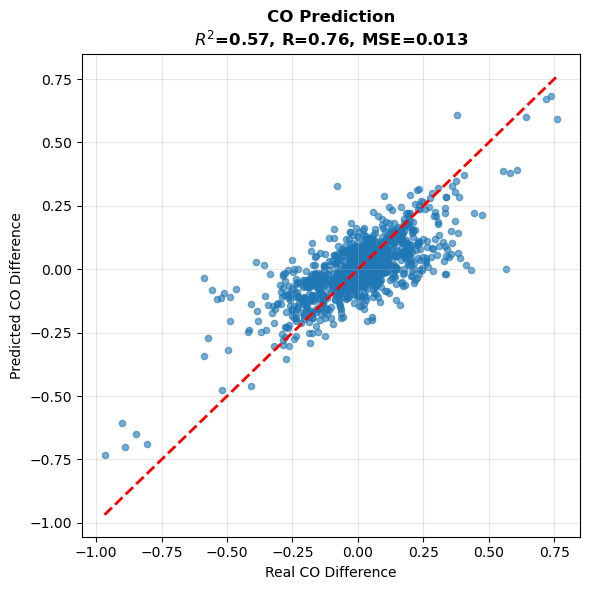


===== CO Test Metrics =====
R²: 0.572 | R: 0.758 | MSE: 0.013 | MAE: 0.082

Generating FULL CBAM Attention Maps (Channel + Spatial)



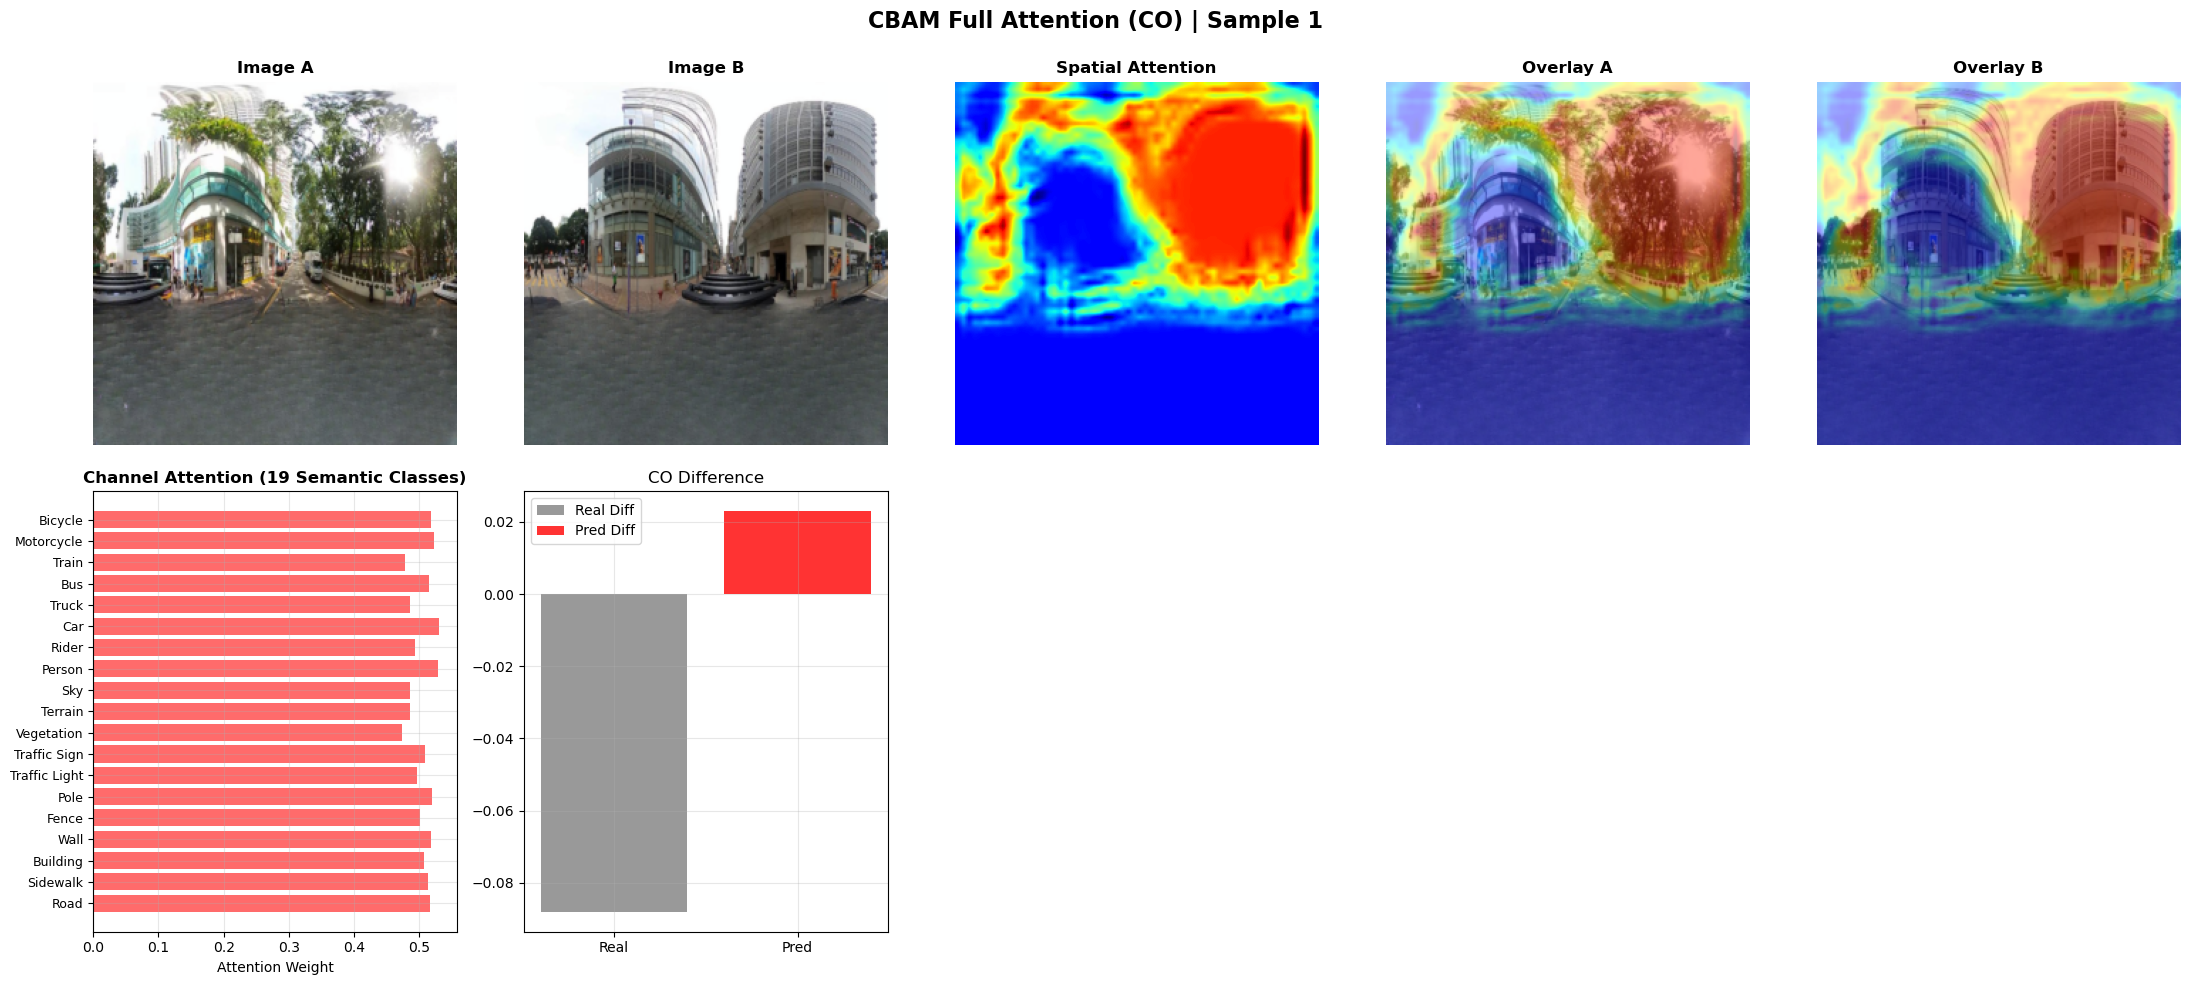

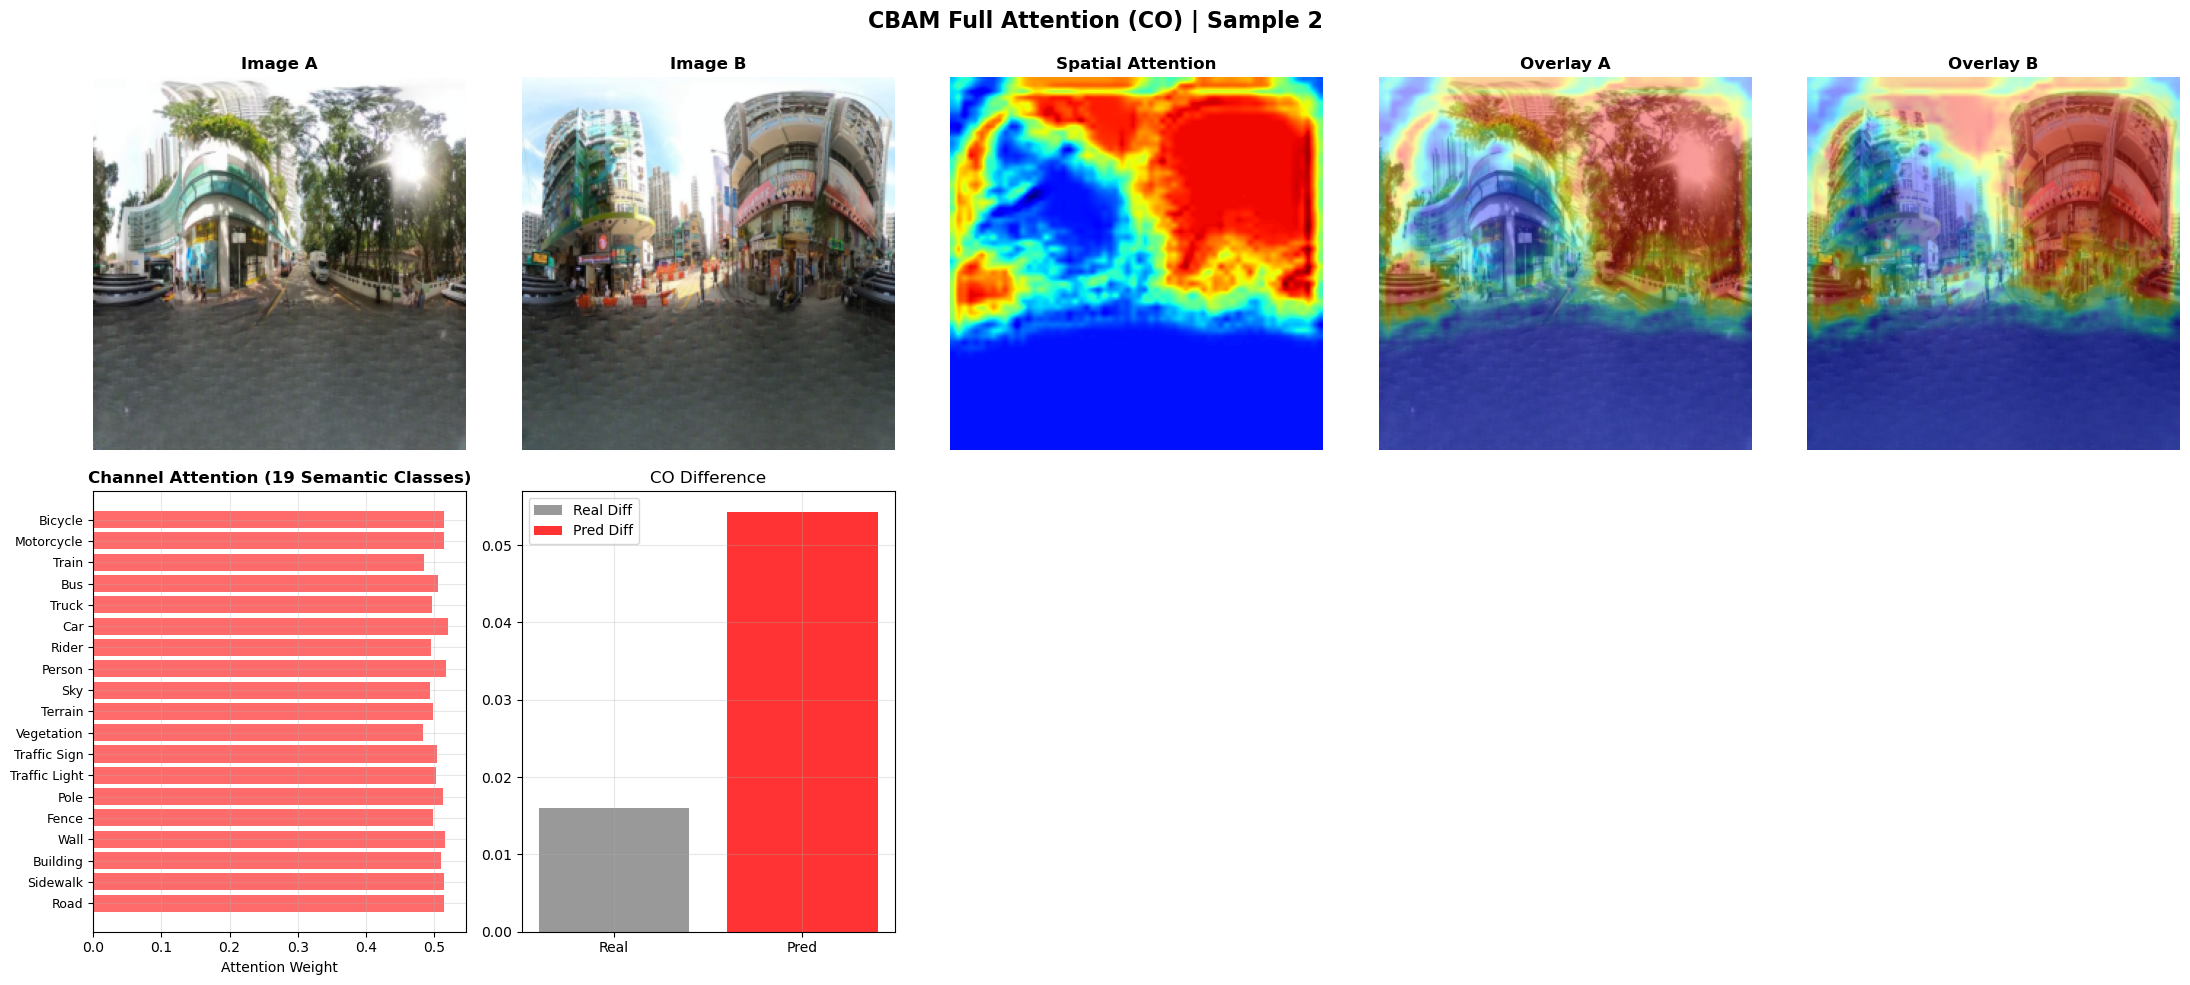

In [5]:
# ==========================================
# 5. Visualization Module → ONLY pollutant + FULL CBAM (Channel + Spatial Attention)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn.functional as F

def visualize_results_pollutant(model, loader, device, dataset, num_samples=2):
    model.eval()
    preds, targets = [], []
    
    # --------------------------
    # 1. pollutant Prediction Scatter Plot (Original Reserved Logic)
    # --------------------------
    with torch.no_grad():
        for imgA, imgB, t in loader:
            p = model(imgA.to(device), imgB.to(device))
            preds.append(p.cpu().numpy())
            targets.append(t.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    plt.figure(figsize=(6,6))
    r2 = r2_score(targets, preds)
    corr, _ = pearsonr(targets.ravel(), preds.ravel())
    mse = mean_squared_error(targets, preds)
    mae = mean_absolute_error(targets, preds)

    plt.scatter(targets, preds, s=20, alpha=0.6, color='#1f77b4')
    plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--', lw=2)
    plt.title(f"pollutant Prediction\n$R^2$={r2:.2f}, R={corr:.2f}, MSE={mse:.3f}", fontweight='bold')
    plt.xlabel("Real pollutant Difference")
    plt.ylabel("Predicted pollutant Difference")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n===== pollutant Test Metrics =====")
    print(f"R²: {r2:.3f} | R: {corr:.3f} | MSE: {mse:.3f} | MAE: {mae:.3f}")

    # --------------------------
    # 2. Full CBAM Visualization: Channel Attention + Spatial Attention
    # --------------------------
    print("\nGenerating FULL CBAM Attention Maps (Channel + Spatial)\n")
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    def denorm(img_tensor):
        return np.clip(img_tensor.permute(1,2,0).cpu().numpy() * std + mean, 0, 1)

    # 19 semantic category labels corresponding to Cityscapes dataset (for channel attention)
    channel_names = [
        "Road","Sidewalk","Building","Wall","Fence","Pole",
        "Traffic Light","Traffic Sign","Vegetation","Terrain",
        "Sky","Person","Rider","Car","Truck","Bus",
        "Train","Motorcycle","Bicycle"
    ]

    for sample_idx in range(num_samples):
        imgA_t, imgB_t, target_diff = dataset[sample_idx]
        imgA = imgA_t.unsqueeze(0).to(device)
        imgB = imgB_t.unsqueeze(0).to(device)

        with torch.no_grad():
            # 1. Extract semantic feature maps and differential feature map
            map1 = model.get_semantic_map(imgA)
            map2 = model.get_semantic_map(imgB)
            diff_map = map2 - map1

            # 2. Extract two branches of CBAM attention weights
            ca = model.cbam.ca(diff_map)          # Channel Attention (19 semantic channels)
            sa = model.cbam.sa(diff_map * ca)     # Spatial Attention

            # 3. Process Channel Attention → Importance weight of 19 semantic channels
            ca_np = ca.squeeze().cpu().numpy()    # shape [19]
            
            # 4. Process Spatial Attention → Spatial heatmap
            sa_map = F.interpolate(sa, size=(256,256), mode='bilinear', align_corners=False)
            sa_map = sa_map.squeeze().cpu().numpy()
            sa_map = (sa_map - sa_map.min()) / (sa_map.max() - sa_map.min() + 1e-8)

            # 5. pollutant prediction result
            pred_diff = model(imgA, imgB).item()

        # --------------------------
        # Combined plot layout: Raw Images + Channel Attention + Spatial Attention + Overlay Heatmap + pollutant Prediction Result
        # --------------------------
        fig = plt.figure(figsize=(22, 10))
        fig.suptitle(f'CBAM Full Attention (pollutant) | Sample {sample_idx+1}', fontsize=16, fontweight='bold')

        # Row 1: Raw input images + spatial attention overlay
        ax1 = plt.subplot(2,5,1)
        ax1.imshow(denorm(imgA_t))
        ax1.set_title('Image A', fontweight='bold')
        ax1.axis('off')

        ax2 = plt.subplot(2,5,2)
        ax2.imshow(denorm(imgB_t))
        ax2.set_title('Image B', fontweight='bold')
        ax2.axis('off')

        ax3 = plt.subplot(2,5,3)
        ax3.imshow(sa_map, cmap='jet')
        ax3.set_title('Spatial Attention', fontweight='bold')
        ax3.axis('off')

        ax4 = plt.subplot(2,5,4)
        ax4.imshow(denorm(imgA_t)*0.6 + plt.cm.jet(sa_map)[...,:3]*0.4)
        ax4.set_title('Overlay A', fontweight='bold')
        ax4.axis('off')

        ax5 = plt.subplot(2,5,5)
        ax5.imshow(denorm(imgB_t)*0.6 + plt.cm.jet(sa_map)[...,:3]*0.4)
        ax5.set_title('Overlay B', fontweight='bold')
        ax5.axis('off')

        # Row 2: Channel Attention bar chart (19 semantic class weights) + pollutant prediction comparison
        ax6 = plt.subplot(2,5,6)
        colors = ['#ff6b6b','#4ecdc4','#45b7d1','#96ceb4','#ffeaa7']*4
        ax6.barh(np.arange(len(channel_names)), ca_np, color=colors[0])
        ax6.set_yticks(np.arange(len(channel_names)))
        ax6.set_yticklabels(channel_names, fontsize=9)
        ax6.set_xlabel('Attention Weight')
        ax6.set_title('Channel Attention (19 Semantic Classes)', fontweight='bold')
        ax6.grid(alpha=0.3)

        # pollutant difference comparison bar chart
        ax7 = plt.subplot(2,5,7)
        ax7.bar(['Real'], [target_diff.item()], color='gray', alpha=0.8, label='Real Diff')
        ax7.bar(['Pred'], [pred_diff], color='red', alpha=0.8, label='Pred Diff')
        ax7.set_title('pollutant Difference')
        ax7.legend()
        ax7.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

# --------------------------
# Execution Entry: Draw scatter plot + complete CBAM attention visualization
# --------------------------
visualize_results_pollutant(model, test_loader, device, test_dataset, num_samples=2)

In [6]:
import os
import torch
from PIL import Image
import torchvision.transforms as T
import numpy as np
import pandas as pd

def run_pollution_inference_pollutant(model_path, img_path_A, target_path, known_pollutant_A, device, output_csv="inference_results_pollutant.csv"):
    """
    pollutant Dedicated Inference Function: Only predicts carbon monoxide concentration
    Predicts ONLY pollutant concentration for Image B based on reference Image A.
    """
    pollutants = ['pollutant']  # Retain pollutant only

    # ---------------------------------------------------------
    # 1. Model & Input Initialization
    # ---------------------------------------------------------
    print("Initializing pollutant prediction model and loading reference Image A...")
    transform = T.Compose([
        T.Resize((256, 256)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # pollutant-specified model configuration: pollution_dims set to 1 for single output channel
    model = PollutionDifferenceModel(num_classes=19, pollution_dims=1).to(device)
    
    # Load model checkpoint weights
    checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint['model'])
        
    model.eval()

    # Load reference image A
    try:
        img_A = Image.open(img_path_A).convert('RGB')
        tensor_A = transform(img_A).unsqueeze(0).to(device)
    except Exception as e:
        print(f"ERROR: Failed to load Reference Image A: {e}")
        return None

    # Single scalar input required for pollutant only
    known_A_np = np.array([known_pollutant_A], dtype=np.float32)

    # ---------------------------------------------------------
    # 2. Judge Target Input Type (Single File / Directory)
    # ---------------------------------------------------------
    if os.path.isfile(target_path):
        target_files = [target_path]
        is_directory = False
    elif os.path.isdir(target_path):
        target_files = [
            os.path.join(target_path, f) for f in os.listdir(target_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        is_directory = True
        print(f"Detected {len(target_files)} target images. Starting pollutant batch inference...")
    else:
        print(f"Error: Target path '{target_path}' does not exist.")
        return None

    # ---------------------------------------------------------
    # 3. Inference Loop (pollutant-only prediction)
    # ---------------------------------------------------------
    results_list = []

    with torch.no_grad():
        for t_file in target_files:
            try:
                img_B = Image.open(t_file).convert('RGB')
                tensor_B = transform(img_B).unsqueeze(0).to(device)
            except Exception as e:
                print(f"Skipping {t_file}: loading error - {e}")
                continue

            # Predict pollutant concentration difference between A and B
            pred_diff = model(tensor_A, tensor_B).squeeze(0).cpu().numpy()
            pred_pollutant_B = np.clip(known_A_np - pred_diff, a_min=0, a_max=None)

            # Record prediction result
            result_row = {'Filename': os.path.basename(t_file), 'pollutant': pred_pollutant_B[0]}
            results_list.append(result_row)

            # Print detailed output for single image mode
            if not is_directory:
                print("\n" + "=" * 50)
                print(f"pollutant INFERENCE RESULT: {os.path.basename(t_file)}")
                print("=" * 50)
                print(f"{'Item':<10} | {'Value':<15}")
                print("-" * 30)
                print(f"{'Known A':<10} | {known_A_np[0]:<15.4f}")
                print(f"{'Pred Diff':<10} | {pred_diff[0]:<15.4f}")
                print(f"{'Pred B':<10} | {pred_pollutant_B[0]:<15.4f}")
                print("=" * 50)
            # Print progress dot for batch folder mode
            else:
                print(".", end="", flush=True)

    # ---------------------------------------------------------
    # 4. Export All Predictions to CSV File
    # ---------------------------------------------------------
    if is_directory and results_list:
        df = pd.DataFrame(results_list)
        df.to_csv(output_csv, index=False)
        print(f"\npollutant batch predictions saved to file: {output_csv}")

    return results_list

# ==========================================
# pollutant Dedicated Usage Example
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Path to trained pollutant-only model checkpoint (best_pollutant_model.pth saved during training)
    SAVED_MODEL_PATH = "best_pollutant_model.pth"
    
    IMAGE_A_PATH = "output_frames_20251110/"
    
    # Single input value required: reference pollutant concentration of Image A
    KNOWN_pollutant_A = 0.714  # Fill reference pollutant concentration here

    # Single target image inference
    TARGET_PATH = "output_frames_20251110/image202511081320.jpg"

    # Batch folder inference (uncomment below to enable)
    # TARGET_PATH = "output_frames_20251108/"

    # Execute inference pipeline
    results = run_pollution_inference_pollutant(
        model_path=SAVED_MODEL_PATH,
        img_path_A=IMAGE_A_PATH,
        target_path=TARGET_PATH,
        known_pollutant_A=KNOWN_pollutant_A,
        device=device,
        output_csv="batch_predictions_pollutant.csv"
    )

Initializing CO model & processing Reference Image A...


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

ERROR: Failed to load Reference Image A: [Errno 13] Permission denied: 'output_frames_20251110/'
